In [77]:
# -----------------------------
# Import libraries
# -----------------------------

from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
from sklearn.metrics import make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from string import ascii_uppercase
from geopy.distance import geodesic
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from xgboost import XGBRegressor
#from tqdm import tqdm
import time
from scipy.stats import uniform
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [78]:
pnw = pd.read_csv(
    "../data/taxonomic/NCASIpollen_tax.csv",
    encoding="latin1",
    low_memory=False
)

# Columns you expect to exist
cols = ["SampleID", "Stand"]

# Keep only columns that are actually present in the CSV
cols = [c for c in cols if c in pnw.columns]

# Collect RBCL columns
rbcl_cols = [c for c in pnw.columns if c.startswith("RBCL:")]

# Subset the dataframe (make a copy to avoid warnings)
pnw_sub = pnw[cols + rbcl_cols].copy()

# Create UniqueID and Site safely
if "SampleID" in pnw_sub.columns:
    pnw_sub["UniqueID"] = pnw_sub["SampleID"]

if "Stand" in pnw_sub.columns:
    pnw_sub["Site"] = pnw_sub["Stand"]

# Final column order
new_cols = [c for c in ["UniqueID", "Site"] if c in pnw_sub.columns]

pnw_final = pnw_sub[new_cols + rbcl_cols]

pnw_final["Project"] = "PNW"

pnw_final.head()


C:\Users\rah10\AppData\Local\Temp\ipykernel_71760\3525650102.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pnw_final["Project"] = "PNW"


,UniqueID,Site,RBCL:Rubus_chamaemorus,RBCL:Daucus_carota,RBCL:Salvia_sp,RBCL:Prunella_vulgaris,RBCL:Cichorium_intybus,RBCL:Symphoricarpos_occidentalis,RBCL:Verbascum_sp,RBCL:Viburnum_acerifolium,RBCL:Berberis_sp,RBCL:Viburnum_sp,RBCL:Spiraea_sp,RBCL:Caprifoliaceae_sp,RBCL:Prunus_sp,RBCL:Asteraceae_sp,RBCL:Vicia_cirrhosa,RBCL:Allium_sp,RBCL:Vicia_sp,RBCL:Tiquilia_paronychioides,RBCL:Cicuta_sp,RBCL:Glycine_sp,RBCL:Campanula_sp,RBCL:Dicentra_sp,RBCL:Ceanothus_sp,RBCL:Salix_sp,RBCL:Aegopodium_sp,RBCL:Medicago_sp,RBCL:Sambucus_sp,RBCL:Dicentra_formosa,RBCL:Iris_missouriensis,RBCL:Lupinus_sp,RBCL:Sphagneticola_trilobata,RBCL:Galium_sp,RBCL:Rosaceae_sp,RBCL:Senecio_sp,RBCL:Alnus_sp,RBCL:Plantago_sp,RBCL:Phacelia_heterophylla,RBCL:Rubus_sp,RBCL:Digitalis_sp,RBCL:Achillea_sp,RBCL:Stachys_sp,RBCL:Ericaceae_sp,RBCL:Fagaceae_sp,RBCL:Daucus_sp,RBCL:Sium_sp,RBCL:Gaultheria_sp,RBCL:Scrophularia_sp,RBCL:Apiales_sp,RBCL:Cirsium_sp,RBCL:Crepis_sp,RBCL:Holodiscus_sp,RBCL:Chamerion_sp,RBCL:Trifolium_sp,RBCL:Ligustrum_sp,RBCL:Cichorium_sp,RBCL:Lotus_sp,RBCL:Hypericum_sp,RBCL:Lamiales_sp,RBCL:Fabaceae_sp,RBCL:Rhamnus_sp,RBCL:Quercus_sp,RBCL:Arceuthobium_sp,RBCL:Lamiaceae_sp,RBCL:Arctium_sp,RBCL:Capsella_sp,RBCL:Lithocarpus_sp,RBCL:Potentilla_sp,RBCL:Prunella_sp,RBCL:Hypericum_elodeoides,Project
0,NCASI-S63152,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
1,NCASI-S63154,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
2,NCASI-S63138,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
3,NCASI-S63135,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
4,NCASI-S63145,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW


In [79]:
## import data

ca = pd.read_csv("../data/taxonomic/FFARpollen_tax.csv", encoding="latin1", low_memory=False)

cols = ["UniqueID", "Site"]

rbcl_cols = [c for c in ca.columns if c.startswith("RBCL:")]

ca_sub = ca[cols + rbcl_cols]

ca_sub["Project"] = "CA"
ca_sub.head()


C:\Users\rah10\AppData\Local\Temp\ipykernel_71760\3879061384.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_sub["Project"] = "CA"


,UniqueID,Site,RBCL:Pertusadina_eurhyncha,RBCL:Trifolium_angustifolium,RBCL:Daucus_carota,RBCL:Oxalis_pes-caprae,RBCL:Cucumus_melo,RBCL:Eleocharis_sp,RBCL:Apiaceae_sp.1,RBCL:Taraxacum_officinale,RBCL:Rubus_ursinus,RBCL:Cucurbita_pepo,RBCL:Matricaria_matricarioides,RBCL:Lamiaceae_sp.1,RBCL:Schoenoplectus_lacustris,RBCL:Brassica_rapa,RBCL:Lotus_japonicus,RBCL:Cucurbitaceae_sp.1,RBCL:Viburnum_sp,RBCL:Pisum_sativum,RBCL:Betulaceae_sp,RBCL:Lamiaceae_sp.2,RBCL:Tamaricaceae_sp,RBCL:Senna_sp,RBCL:Achillea_millefolium,RBCL:Cinnamomum_sp,RBCL:Plantago_sp,RBCL:Apiaceae_sp.2,RBCL:Erigeron_canadensis,RBCL:Medicago_sp,RBCL:Helianthus_annuus,RBCL:Capsella_bursa-pastoris,RBCL:Cicuta_maculata,RBCL:Quercus_sp,RBCL:Convolvulus_arvensis,RBCL:Cucurbitaceae_sp.2,RBCL:Actinidia_arguta,RBCL:Salvia_sp.1,RBCL:Cichorium_intybus,RBCL:Citrus_sp,RBCL:Prunus_cerasus,RBCL:Apiaceae_sp.3,RBCL:Rubiaceae_sp,RBCL:Lamiaceae_sp.3,RBCL:Commelinaceae_sp,RBCL:Salvia_sp.2,RBCL:Helminthotheca_echioides,RBCL:Ceanothus_lemmonii,RBCL:Zygophyllaceae_sp,RBCL:Boraginaceae_sp,RBCL:Fraxinus_sp,RBCL:Lauraceae_sp.1,RBCL:Cucurbitaceae_sp.3,RBCL:Marrubium_vulgare,RBCL:Solanum_parishii,RBCL:Salvia_sp.3,RBCL:Phacelia_heterophylla,RBCL:Acmispon_glaber,RBCL:Tamarix_usneoides,RBCL:Asclepias_sp.1,RBCL:Apiaceae_sp.4,RBCL:Allium_sp,RBCL:Meehania_sp,RBCL:Lonicera_orientalis,RBCL:Cornus_nuttallii,RBCL:Asphodelaceae_sp,RBCL:Plumbaginaceae_sp,RBCL:Helianthus_sp,RBCL:Zinnia_elegans,RBCL:Conium_maculatum,RBCL:Camassia_sp,RBCL:Eschscholzia_californica,RBCL:Malva_parviflora,RBCL:Buddleja_davidii,RBCL:Polygonum_sp,RBCL:Albizia_niopoides,RBCL:Crataegus_pinnatifida,RBCL:Antirrhinum_majus,RBCL:Rhamnaceae_sp,RBCL:Rutaceae_sp,RBCL:Rosa_californica,RBCL:Vicia_sp,RBCL:Rosaceae_sp,RBCL:Raphanus_sativus,RBCL:Araceae_sp,RBCL:Apiaceae_sp.5,RBCL:Adenostoma_fasciculatum,RBCL:Erodium_brachycarpum,RBCL:Juglans_regia,RBCL:Solanum_lycopersicum,RBCL:Pouteria_sp,RBCL:Malus_domestica,RBCL:Alnus_sp,RBCL:Taraxacum_brevicorniculatum,RBCL:Fagaceae_sp,RBCL:Salvia_sp.4,RBCL:Phyla_nodiflora,RBCL:Ailanthus_altissima,RBCL:Apocynaceae_sp,RBCL:Eriogonum_sp,RBCL:Ramnus_crenata,RBCL:Fragaria_sp,RBCL:Lamiaceae_sp.4,RBCL:Cucurbitaceae_sp.4,RBCL:Arecaceae_sp,RBCL:Thymelaeaceae_sp,RBCL:Heliotropium_sp,RBCL:Asteraceae_sp.1,RBCL:Lamiaceae_sp.5,RBCL:Papaveraceae_sp.1,RBCL:Asteraceae_sp.2,RBCL:Lamiaceae_sp.6,RBCL:Castanea_sp,RBCL:Fabaceae_sp,RBCL:Apiaceae_sp,RBCL:Lamiaceae_sp,RBCL:Cucurbitaceae_sp,RBCL:Salvia_sp,RBCL:Lauraceae_sp,RBCL:Asclepias_sp,RBCL:Asteraceae_sp,RBCL:Papaveraceae_sp,Project
0,SF266,Turk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.940520,0.0,0.0,0.0,0.038104,0.0,0.0,0.021375,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CA
1,SF303,Turk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CA
2,SF305,Turk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.978625,0.0,0.0,0.0,0.008364,0.0,0.0,0.010223,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [80]:
## import data

si = pd.read_csv("../data/taxonomic/SIpollen_tax.csv", encoding="latin1", low_memory=False)

cols = ["UniqueID", "Site"]

rbcl_cols = [c for c in si.columns if c.startswith("RBCL:")]

si_sub = si[cols + rbcl_cols]

si_sub["Project"] = "SI"
si_sub.shape

C:\Users\rah10\AppData\Local\Temp\ipykernel_71760\1681525106.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  si_sub["Project"] = "SI"


(19031, 28)

In [81]:
# This will display all columns without truncation.
pd.set_option('display.max_columns', None)

## merging all dataframes for projects
df_merged = (
    pnw_final.merge(si_sub, on=["UniqueID", "Site", "Project"], how="outer")
       .merge(ca_sub, on=["UniqueID", "Site", "Project"], how="outer")
)


In [82]:
import pandas as pd

## combining columns from different datasets with the same id

# Find columns with "_x" suffix
for col in df_merged.columns:
    if col.endswith("_x"):
        base = col[:-2]  # remove "_x"
        col_y = base + "_y"
        
        if col_y in df_merged.columns:
            # Combine the two columns (take max, sum, or first non-null)
            df_merged[base] = df_merged[[col, col_y]].max(axis=1)
            # Drop the old _x and _y columns
            df_merged.drop(columns=[col, col_y], inplace=True)
        else:
            # If no _y column exists, just rename _x to base
            df_merged.rename(columns={col: base}, inplace=True)

# Rename any remaining _y columns (that didn't have _x) to base
for col in df_merged.columns:
    if col.endswith("_y"):
        df_merged.rename(columns={col: col[:-2]}, inplace=True)


In [83]:
rbcl_cols = [c for c in df_merged.columns if c.startswith("RBCL:")]

all_pollen_clean = df_merged.dropna(subset=rbcl_cols, how="all")
all_pollen_clean.shape

(1582, 188)

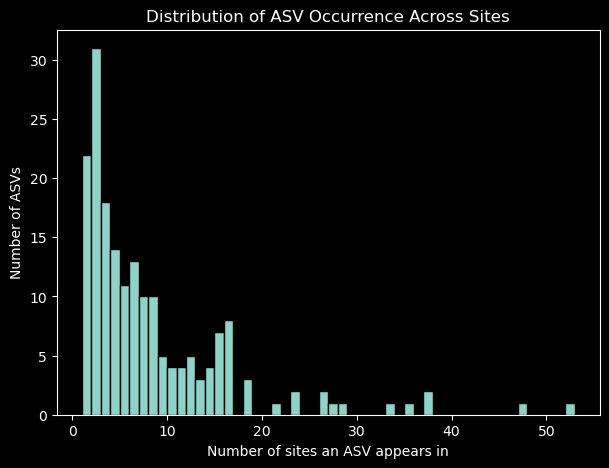

In [84]:
## plotting distribution of ASVs across sites
# Separate metadata and ASV abundance columns
meta_cols = ["UniqueID", "Site", "Project"]  # adjust names as needed
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# Convert relative abundance to presence/absence
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# Count in how many sites each ASV occurs
asv_site_counts = presence.groupby(all_pollen_clean["Site"]).sum().astype(bool).sum(axis=0)

# Plot
plt.figure(figsize=(7,5))
plt.hist(asv_site_counts, bins=range(1, asv_site_counts.max()+2), edgecolor='black')
plt.xlabel("Number of sites an ASV appears in")
plt.ylabel("Number of ASVs")
plt.title("Distribution of ASV Occurrence Across Sites")
plt.show()

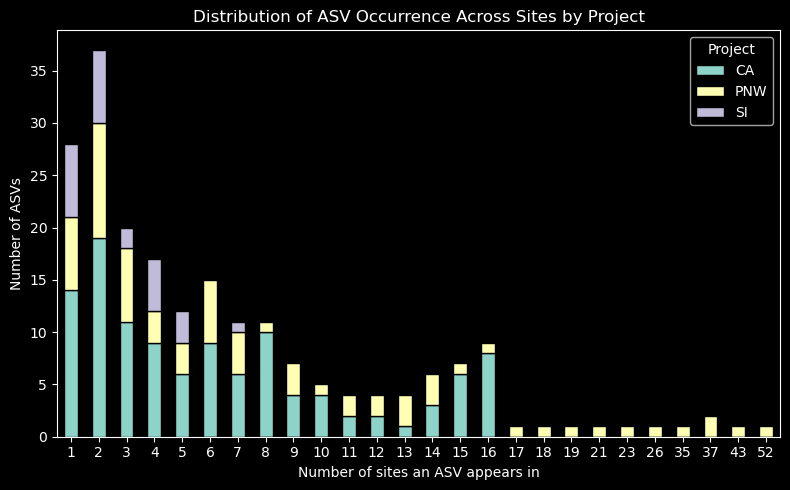

In [85]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Separate metadata and ASV columns ---
meta_cols = ["UniqueID", "Site", "Project"]
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# --- 2. Convert relative abundance to presence/absence ---
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# --- 3. Add metadata back ---
presence[meta_cols] = all_pollen_clean[meta_cols]

# --- 4. Count in how many sites each ASV occurs per Project ---
# Melt to long format
presence_long = presence.melt(id_vars=meta_cols, value_vars=asv_cols,
                              var_name="ASV", value_name="Presence")

# Keep only present (1) entries
presence_long = presence_long[presence_long["Presence"] == 1]

# Count in how many **sites** each ASV appears, grouped by Project
asv_site_counts = presence_long.groupby(["Project", "ASV"])["Site"].nunique().reset_index()
asv_site_counts.rename(columns={"Site": "NumSites"}, inplace=True)

# --- 5. Create a histogram table (ASVs vs number of sites, stacked by Project) ---
hist_table = asv_site_counts.groupby(["NumSites", "Project"]).size().unstack(fill_value=0)

# --- 6. Plot stacked bar chart ---
hist_table.plot(kind="bar", stacked=True, figsize=(8,5), edgecolor='black')

plt.xlabel("Number of sites an ASV appears in")
plt.ylabel("Number of ASVs")
plt.title("Distribution of ASV Occurrence Across Sites by Project")
plt.xticks(rotation=0)
plt.legend(title="Project")
plt.tight_layout()
plt.show()


In [87]:
!pip install matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45437 sha256=598d18b2d6ab3038a816b7ca59f4f63ef7fbf07d4f9a68602fd7f78e0060acfc
  Stored in directory: c:\users\rah10\appdata\local\pip\cache\wheels\86\29\d8\0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib-venn


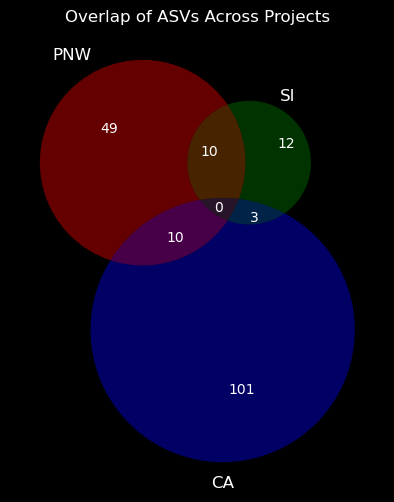

In [88]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# --- 1. Get unique ASVs per project ---
projects = presence_long["Project"].unique()

# Make sure there are exactly 3 projects
if len(projects) != 3:
    raise ValueError("There must be exactly 3 projects for a 3-set Venn diagram")

set1 = set(presence_long.loc[presence_long["Project"] == projects[0], "ASV"])
set2 = set(presence_long.loc[presence_long["Project"] == projects[1], "ASV"])
set3 = set(presence_long.loc[presence_long["Project"] == projects[2], "ASV"])

# --- 2. Plot the Venn diagram ---
plt.figure(figsize=(6,6))
venn3([set1, set2, set3], set_labels=projects)
plt.title("Overlap of ASVs Across Projects")
plt.show()
